# Preparing the dataset for PyTorch training

A lightweight notebook showcasing use of the AMBER dataset via Seisbench and via its own PyTorch dataset. 

In [1]:
from torch.utils.data import DataLoader
from amber import AMBER_DATA_COMPILED
from amber.utils import plot_batch

In [2]:
hdf5_path = AMBER_DATA_COMPILED / "waveforms.hdf5"
csv_path = AMBER_DATA_COMPILED / "metadata.csv"

### Seisbench

In [3]:
import numpy as np
import seisbench.data as sbd
import seisbench.generate as sbg

In [4]:
dts = sbd.WaveformDataset(
    path=hdf5_path.parent,
    metadata=csv_path.name,
    waveforms=hdf5_path.name,
)
test_dataset = dts.get_split("test")
x, meta = test_dataset.get_sample(100)

print(x.shape)
print(meta.keys())

(3, 5156)
dict_keys(['index', 'trace_name', 'split', 'station', 'dataset', 'event_id', 'trace_sampling_rate_hz', 'trace_category', 'trace_start_time', 'trace_p_arrival_sample', 'trace_s_arrival_sample', 'trace_p_length', 'trace_s_length', 'trace_component_order', 'dimension_order', 'trace_p2_arrival_sample', 'trace_s2_arrival_sample', 'trace_p3_arrival_sample', 'trace_s3_arrival_sample', 'trace_p4_arrival_sample', 'trace_s4_arrival_sample', 'trace_chunk', 'trace_source_sampling_rate_hz', 'trace_npts'])


In [5]:
phase_dict = {
    "trace_p_arrival_sample": "P",
    "trace_s_arrival_sample": "S",
}

test_generator = sbg.GenericGenerator(test_dataset)
test_generator.add_augmentations([
    sbg.WindowAroundSample(
        list(phase_dict.keys()),
        samples_before=3000,
        windowlen=6000,
        selection="random",
        strategy="variable",
    ),
    sbg.RandomWindow(windowlen=3001, strategy="pad"),
    sbg.ChangeDtype(np.float32),
    sbg.ProbabilisticLabeller(
        label_columns=phase_dict, sigma=30, dim=0
    ),
    sbg.ChangeDtype(np.float32, key="y"),
])

(5, 3, 3001) (5, 3, 3001)


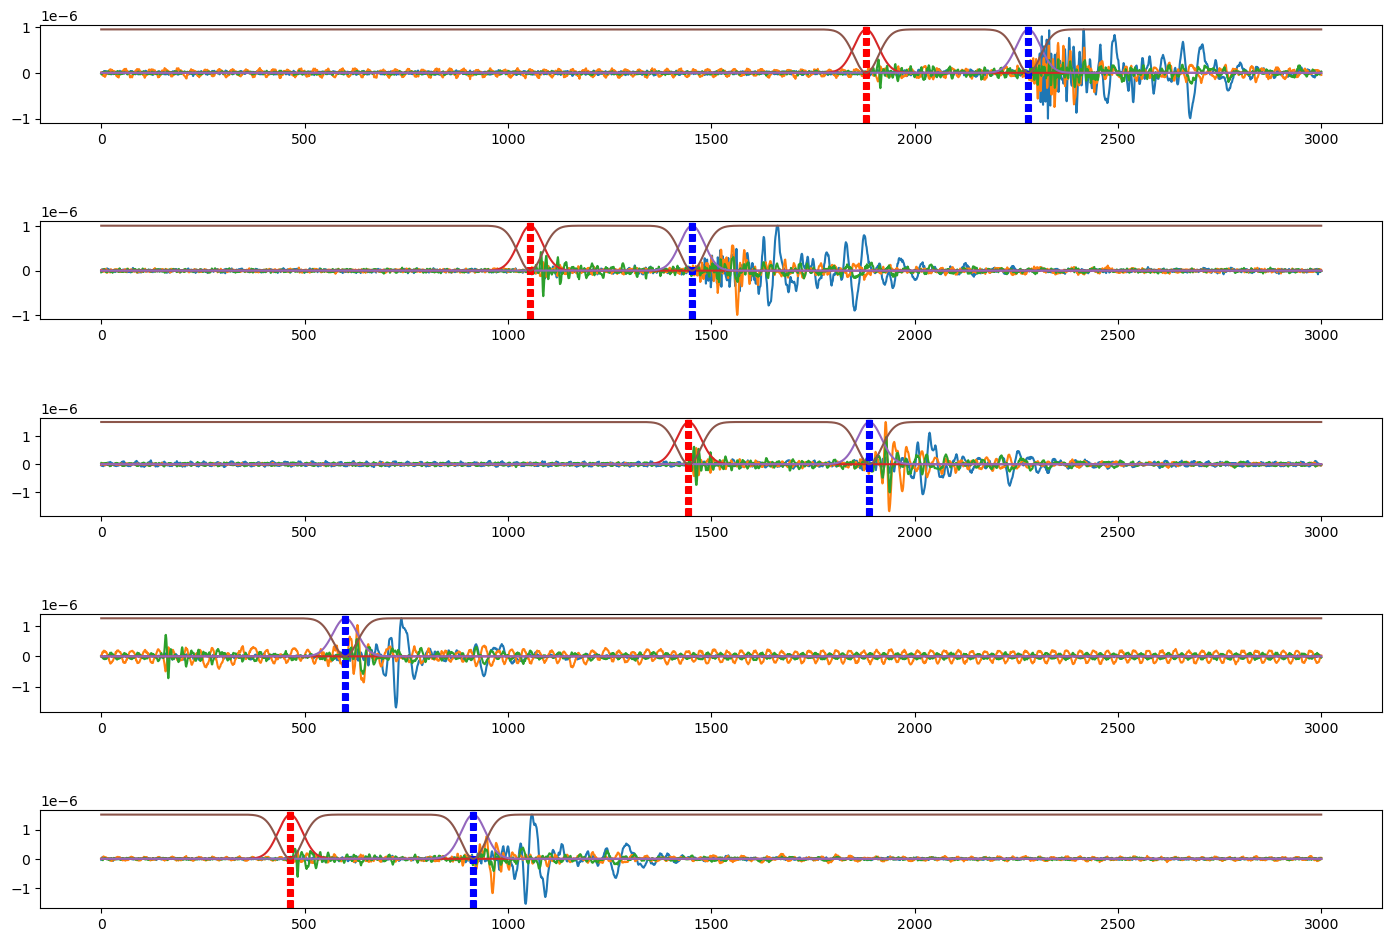

In [6]:
test_dataloader = DataLoader(test_generator, batch_size=5, shuffle=False, drop_last=True)

plot_batch(dataloader=test_dataloader, batch_idx=0)

### AMBER

In [7]:
from amber.dataloaders import AMBER, DatasetConfig
from amber.Augmentations import load_augmentations, AugmentationConfig
from amber.Labeller import create_labeller, LabellerConfig

In [8]:
dtscfg = DatasetConfig(
    windowlength = 4000,
    nstation = 8,
    fullphasecoverage=False
)

augcfg = AugmentationConfig(
    augmentations=[
        {"type": "resample", "params": {"samplingrate": 4000, "windowlength": 4000}},
#         {"type": "random_rotation", "params": {"augment_chance": 1.0}},
        {"type": "random_flip", "params": {"augment_chance": 1.0}},
    ]
)

lblcfg = LabellerConfig(
    dynamic_params={
        "dropoff":50,
        "windowlength":4000
    }
)

augmentations = load_augmentations(augcfg)

labeller = create_labeller("tapered_labeller", lblcfg)

test_dataset = AMBER(dtscfg, hdf5_path, csv_path, labeller, augmentations, "test")

(5, 8, 3, 4000) (5, 8, 3, 4000)


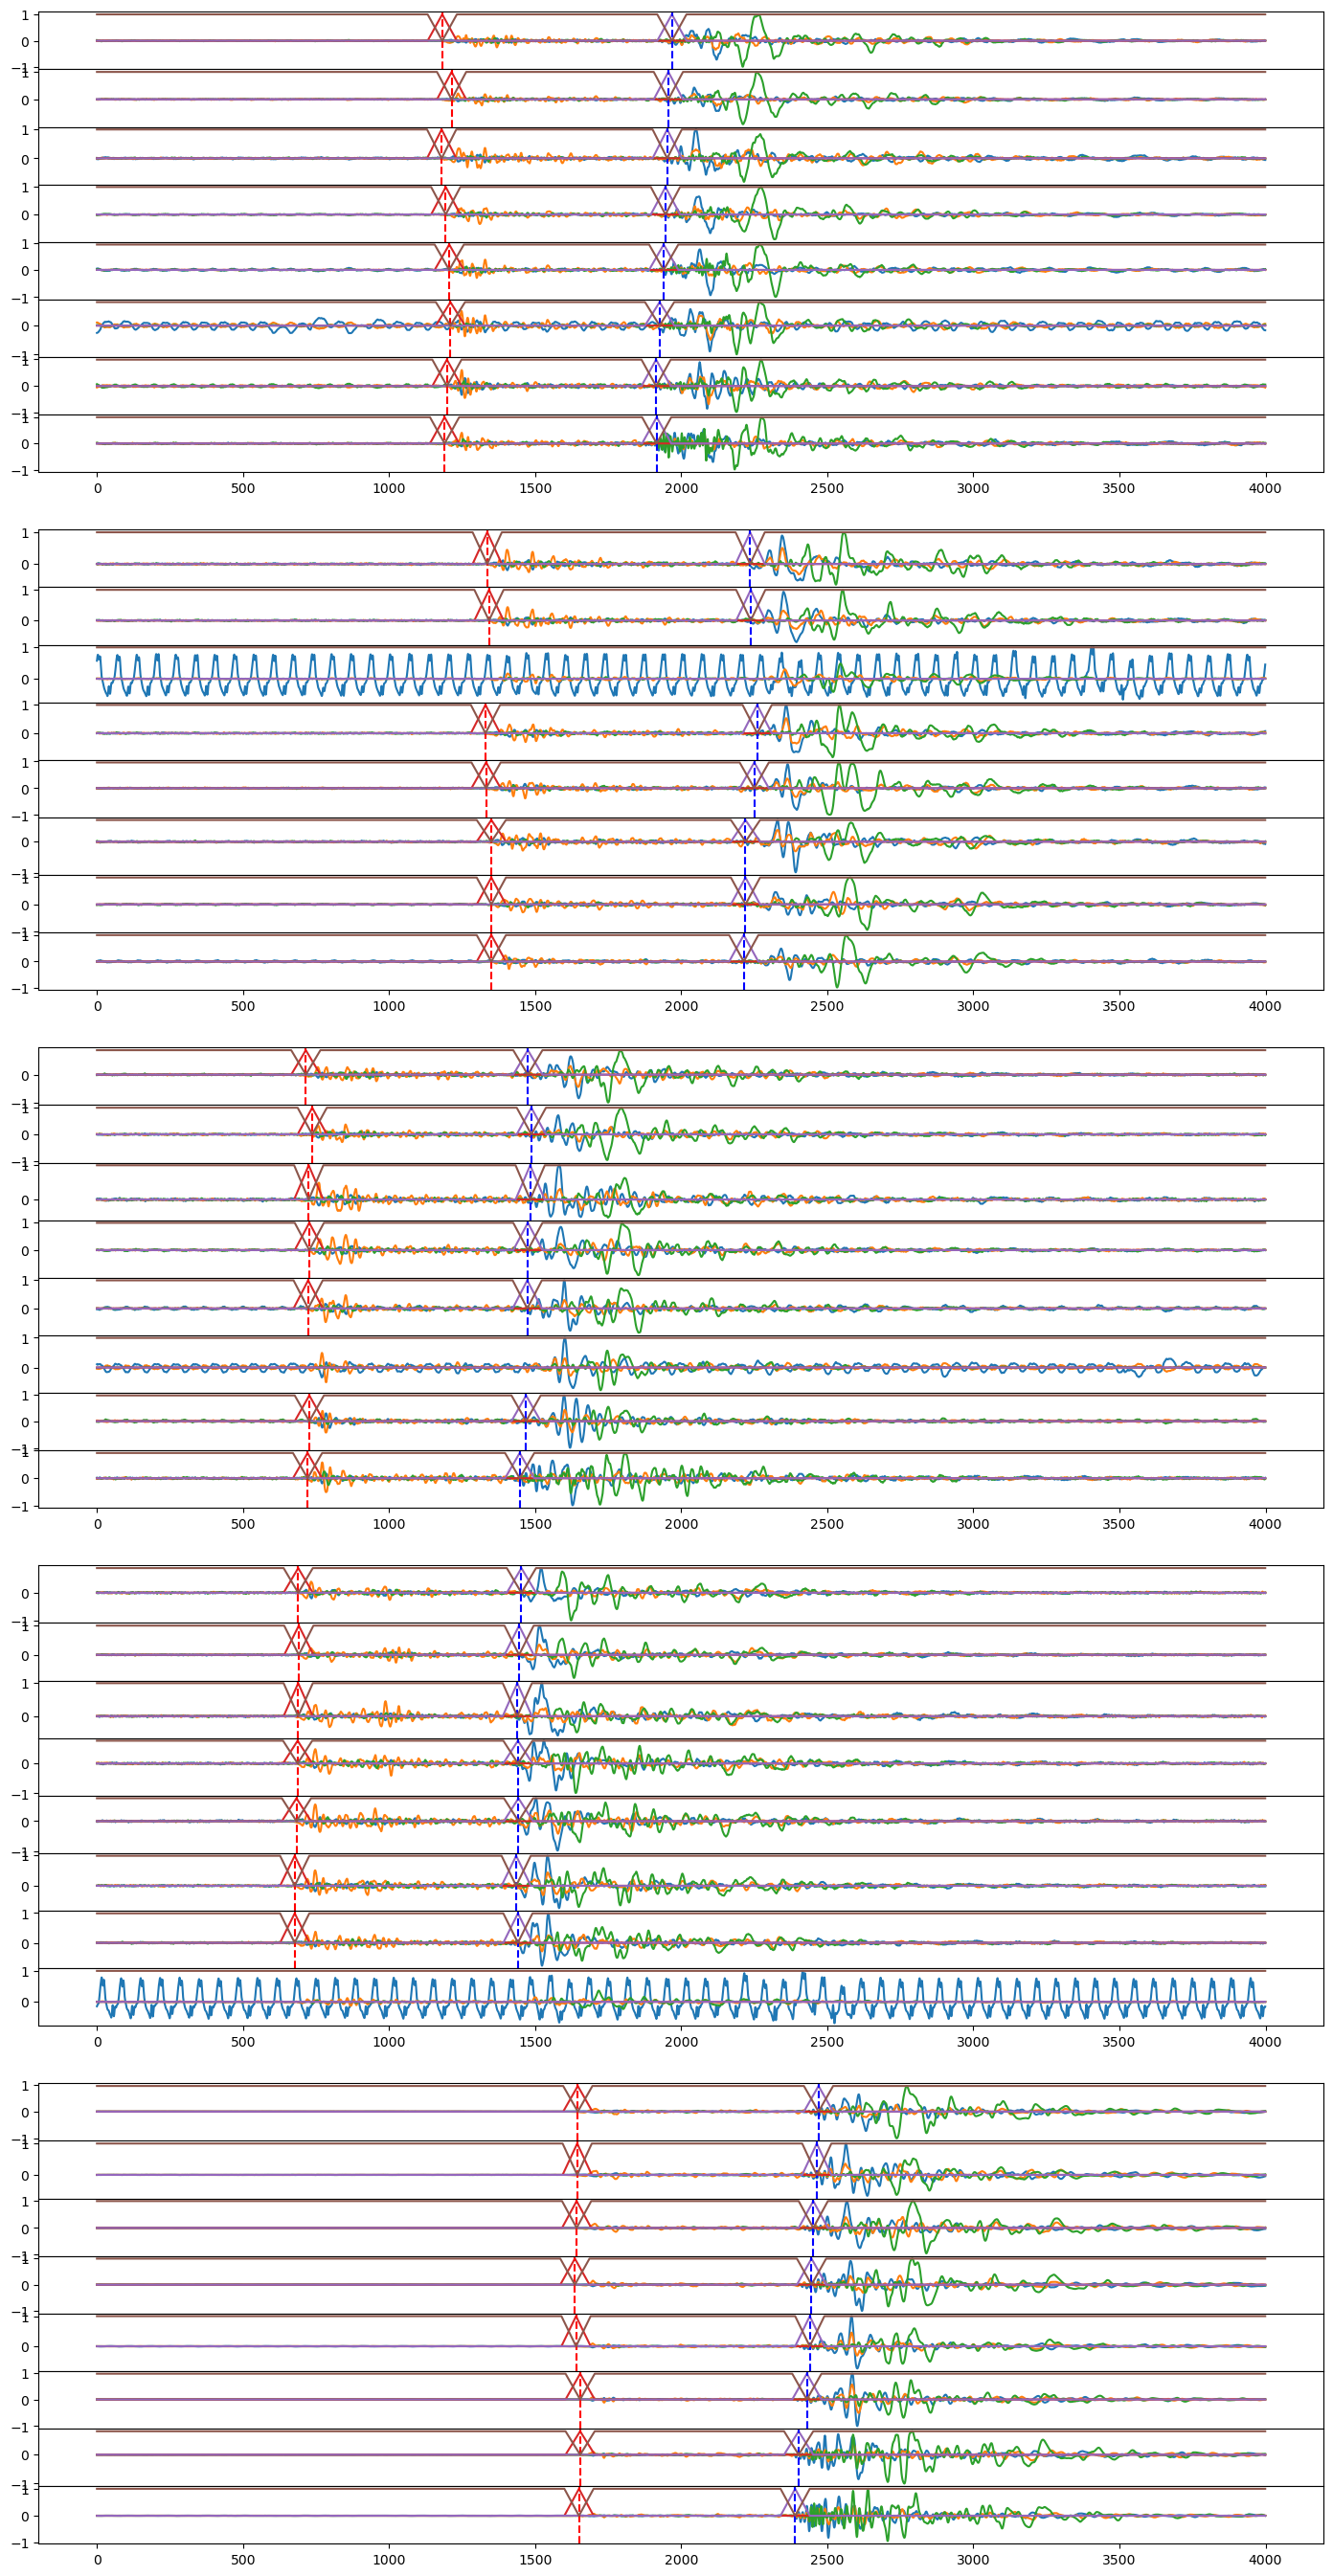

In [9]:
test_dataloader = DataLoader(test_dataset, batch_size=5, shuffle=False, drop_last=True)

plot_batch(dataloader=test_dataloader, batch_idx=0)